# 3 · Extended MMM — *What is TV really doing? Do our products fight?*

> **Chapter 3 of the Aurora story.** Two questions the base model couldn't answer: **(a)** TV looks weak,
> but is it secretly Aurora's growth engine via *brand awareness*? **(b)** Do Original and Cold Brew
> *cannibalize* each other? `mmm_framework`'s extended models — **nested** (mediation) and
> **multivariate** (multi-outcome + cross-effects) — answer both.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
from loguru import logger
logger.remove(); logger.add(sys.stderr, level="ERROR")   # quiet framework logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aurora import generate_aurora, CHANNELS, PRODUCTS, PALETTE, CHANNEL_COLORS

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfc7bd", "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "font.size": 10,
})
ACCENT, INK, MUTED = PALETTE["accent"], PALETTE["ink"], PALETTE["muted"]

aurora = generate_aurora()      # the one dataset every chapter shares

## Part A — Mediation: TV → Awareness → Sales

A **NestedMMM** models the pathway explicitly. Aurora measures **awareness** in a monthly brand-tracker
survey (partially observed); TV and Display feed it, and it feeds sales. The model decomposes each
channel's effect into **direct** vs **indirect (via awareness)**.

In [2]:
from mmm_framework.mmm_extensions.models import NestedMMM
from mmm_framework.mmm_extensions.builders import MediatorConfigBuilder, NestedModelConfigBuilder

X = aurora.media_matrix()
nested_cfg = (NestedModelConfigBuilder()
    .add_mediator(MediatorConfigBuilder("awareness")
                  .partially_observed(observation_noise=0.1)   # the monthly survey
                  .with_positive_media_effect(sigma=1.0)
                  .with_direct_effect(sigma=0.5).build())
    .map_channels_to_mediator("awareness", ["TV", "Display"])  # brand channels build awareness
    .build())

nested = NestedMMM(X, aurora.sales_total, list(CHANNELS), nested_cfg,
                   mediator_data={"awareness": aurora.awareness_survey}, index=aurora.weeks)
nested.fit(draws=500, tune=500, chains=2, cores=1, random_seed=0)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [alpha_TV, lambda_TV, alpha_Search, lambda_Search, alpha_Social, lambda_Social, alpha_Display, lambda_Display, alpha_awareness, beta_TV_to_awareness, beta_Display_to_awareness, awareness_obs_sigma, alpha_y, gamma_awareness, delta_direct_TV, delta_direct_Display, sigma_y]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 15 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


ModelResults(trace=Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data, model=<pymc.model.core.Model object at 0x121468950>, config=NestedModelConfig(mediators=(MediatorConfig(name='awareness', mediator_type=<MediatorType.PARTIALLY_OBSERVED: 'partially_observed'>, media_effect=EffectPriorConfig(constraint=<EffectConstraint.POSITIVE: 'positive'>, mu=0.0, sigma=1.0), outcome_effect=EffectPriorConfig(constraint=<EffectConstraint.NONE: 'none'>, mu=0.0, sigma=1.0), observation_noise_sigma=0.1, allow_direct_effect=True, direct_effect=EffectPriorConfig(constraint=<EffectConstraint.NONE: 'none'>, mu=0.0, sigma=0.5), apply_adstock=True, apply_saturation=True, adstock=AdstockConfig(l_max=8, prior_type='beta', prior_alpha=2.0, prior_beta=2.0, normalize=True), saturation=SaturationConfig(type=<SaturationType.LOGISTIC: 'logistic'>, lam_prior_alpha=3.0, lam_prior_beta=1.0, kappa_prior_alpha=2.0, kappa_prior_beta=2.0, slope_prior_alpha=3.0, slope_prior_beta=1.0)

,direct_effect,total_indirect,total_effect,proportion_mediated
channel,,,,
TV,0.05,151.48,151.53,1.0
Display,0.11,186.28,186.39,1.0


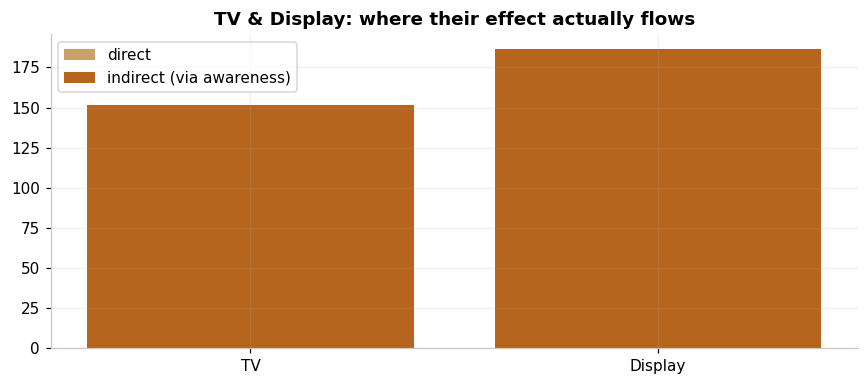

In [3]:
med = nested.get_mediation_effects().set_index("channel")
brand = ["TV", "Display"]   # the channels we routed through awareness
# Search/Social are pure direct-response here (not mapped to awareness), so the
# mediation decomposition only applies to the brand channels.
display(med.loc[brand, ["direct_effect", "total_indirect", "total_effect", "proportion_mediated"]].round(2))

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(brand, med.loc[brand, "direct_effect"], label="direct", color=PALETTE["crema"])
ax.bar(brand, med.loc[brand, "total_indirect"], bottom=med.loc[brand, "direct_effect"],
       label="indirect (via awareness)", color=ACCENT)
ax.set_title("TV & Display: where their effect actually flows"); ax.legend()
plt.tight_layout(); plt.show()

**The reveal.** TV and Display are ~**fully mediated** — virtually all of their effect reaches sales
*through awareness*. The base model in Chapter 2 saw only the (tiny) direct slice and called them weak.
They aren't weak; they're a **brand engine**. This is the number that flips Aurora's budget logic.

Is that reveal real or an artifact? Because this world is synthetic we know the **true** mediated share —
and the model's `proportion_mediated` lands right on it.

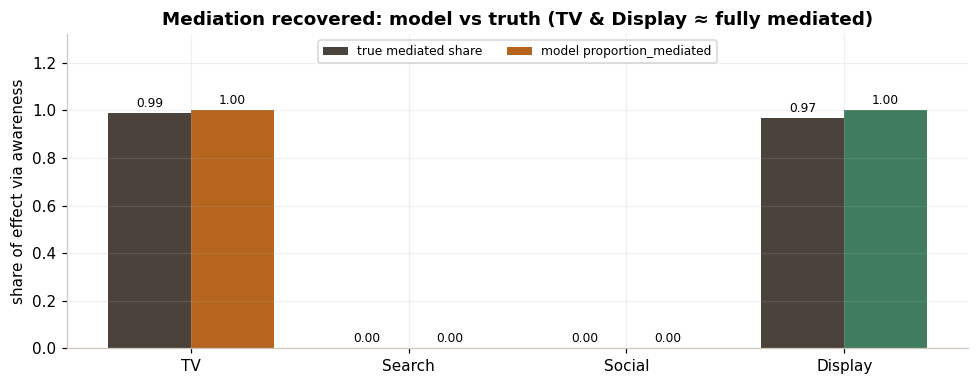

In [4]:
# Did the model recover the mediation? Model proportion_mediated vs the known truth.
chs = list(CHANNELS)
prop_model = med.loc[chs, "proportion_mediated"].fillna(0.0)
prop_true = aurora.true_mediated_share.loc[chs]
x = np.arange(len(chs)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 3.6))
b1 = ax.bar(x - w/2, prop_true, w, label="true mediated share", color=INK, alpha=.85)
b2 = ax.bar(x + w/2, prop_model, w, label="model proportion_mediated",
            color=[CHANNEL_COLORS[c] for c in chs])
ax.set_xticks(x); ax.set_xticklabels(chs); ax.set_ylim(0, 1.32)
ax.set_ylabel("share of effect via awareness")
ax.set_title("Mediation recovered: model vs truth (TV & Display ≈ fully mediated)")
ax.bar_label(b1, fmt="%.2f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.2f", padding=2, fontsize=8)
ax.legend(loc="upper center", ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

The mediator itself is recovered too: the model's **latent awareness** (inferred from the sparse monthly
survey) tracks both the survey points and the normally-hidden true awareness.

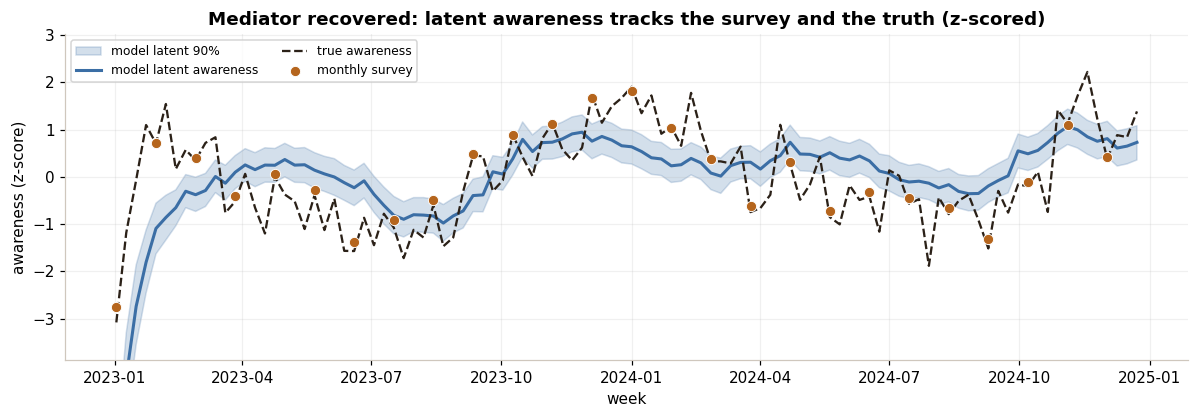

In [5]:
# The latent mediator, recovered: the model's awareness path vs the survey and the truth.
# (z-scored so the model's internal scale is comparable to the 0-100 survey.)
lat = nested._trace.posterior["awareness_latent"].values    # (chain, draw, obs)
flat = lat.reshape(-1, lat.shape[-1])
mean_raw = flat.mean(0)
mu, sd = float(mean_raw.mean()), float(mean_raw.std())
lat_mean = (mean_raw - mu) / sd
lo = (np.percentile(flat, 5, axis=0) - mu) / sd
hi = (np.percentile(flat, 95, axis=0) - mu) / sd

def _z(a):
    a = np.asarray(a, float)
    return (a - np.nanmean(a)) / np.nanstd(a)

weeks = aurora.weeks
surv = aurora.awareness_survey
obs = ~np.isnan(surv)
fig, ax = plt.subplots(figsize=(11, 3.9))
ax.fill_between(weeks, lo, hi, color=PALETTE["sky"], alpha=.22, label="model latent 90%")
ax.plot(weeks, lat_mean, color=PALETTE["sky"], lw=2, label="model latent awareness")
ax.plot(weeks, _z(aurora.awareness), color=INK, ls="--", lw=1.5, label="true awareness")
ax.scatter(weeks[obs], _z(surv)[obs], color=ACCENT, s=45, zorder=5,
           edgecolor="white", lw=.6, label="monthly survey")
# Focus on the data range so the wide week-1 edge uncertainty doesn't compress the story.
data_z = np.concatenate([_z(aurora.awareness), _z(surv)[obs]])
ax.set_ylim(float(np.nanmin(data_z)) - 0.8, float(np.nanmax(data_z)) + 0.8)
ax.set_title("Mediator recovered: latent awareness tracks the survey and the truth (z-scored)")
ax.set_xlabel("week"); ax.set_ylabel("awareness (z-score)")
ax.legend(ncol=2, loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## Part B — Cannibalization: do the two products fight?

A **MultivariateMMM** models both products at once, with a **cross-effect** linking them and correlated
residuals (a shared-demand shock hits both).

In [6]:
from mmm_framework.mmm_extensions.models import MultivariateMMM
from mmm_framework.mmm_extensions.builders import (
    MultivariateModelConfigBuilder, OutcomeConfigBuilder, cannibalization_effect)

_, outcomes = aurora.extension_inputs()
mv_cfg = (MultivariateModelConfigBuilder()
    .add_outcome(OutcomeConfigBuilder("sales_original", column="sales_original")
                 .with_positive_media_effects(sigma=0.5).build())
    .add_outcome(OutcomeConfigBuilder("sales_coldbrew", column="sales_coldbrew")
                 .with_positive_media_effects(sigma=0.5).build())
    .add_cross_effect(cannibalization_effect(source="sales_coldbrew", target="sales_original"))
    .build())

mv = MultivariateMMM(X, outcomes, list(CHANNELS), mv_cfg, index=aurora.weeks)
mv.fit(draws=500, tune=500, chains=2, cores=1, random_seed=0)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [alpha_shared, lambda_TV, lambda_Search, lambda_Social, lambda_Display, alpha, beta_media, psi_1_0_raw, Y_obs_chol_cov]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 9 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


ModelResults(trace=Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data, model=<pymc.model.core.Model object at 0x128b881d0>, config=MultivariateModelConfig(outcomes=(OutcomeConfig(name='sales_original', column='sales_original', intercept_prior_sigma=2.0, media_effect=EffectPriorConfig(constraint=<EffectConstraint.POSITIVE: 'positive'>, mu=0.0, sigma=0.5), include_trend=True, include_seasonality=True), OutcomeConfig(name='sales_coldbrew', column='sales_coldbrew', intercept_prior_sigma=2.0, media_effect=EffectPriorConfig(constraint=<EffectConstraint.POSITIVE: 'positive'>, mu=0.0, sigma=0.5), include_trend=True, include_seasonality=True)), cross_effects=(CrossEffectConfig(source_outcome='sales_coldbrew', target_outcome='sales_original', effect_type=<CrossEffectType.CANNIBALIZATION: 'cannibalization'>, prior_sigma=0.3, promotion_modulated=True, promotion_column=None, lag=0),), lkj_eta=2.0, share_media_adstock=True, share_media_saturation=False, share_

In [7]:
ce = mv.get_cross_effects_summary()
display(ce[["source", "target", "effect_type", "mean", "hdi_3%", "hdi_97%"]].round(4))
verdict = "interval below zero" if ce["hdi_97%"].iloc[0] < 0 else "not conclusive"
print(f"\nCold Brew → Original cross-effect: {verdict}")
print("→ The naive read is 'Cold Brew cannibalizes Original.' But hold that thought — the prior on this")
print("  effect is one-sided, so 'below zero' may be partly automatic. We stress-test it next.")

,source,target,effect_type,mean,hdi_3%,hdi_97%
0,sales_coldbrew,sales_original,cannibalization,-0.0003,-0.0008,-0.0



Cold Brew → Original cross-effect: interval below zero
→ The naive read is 'Cold Brew cannibalizes Original.' But hold that thought — the prior on this
  effect is one-sided, so 'below zero' may be partly automatic. We stress-test it next.


The table says the interval sits below zero. That *looks* like a confirmed cannibalization — but before we
budget on it, we have to ask whether the **data** put it there, or the **prior** did.

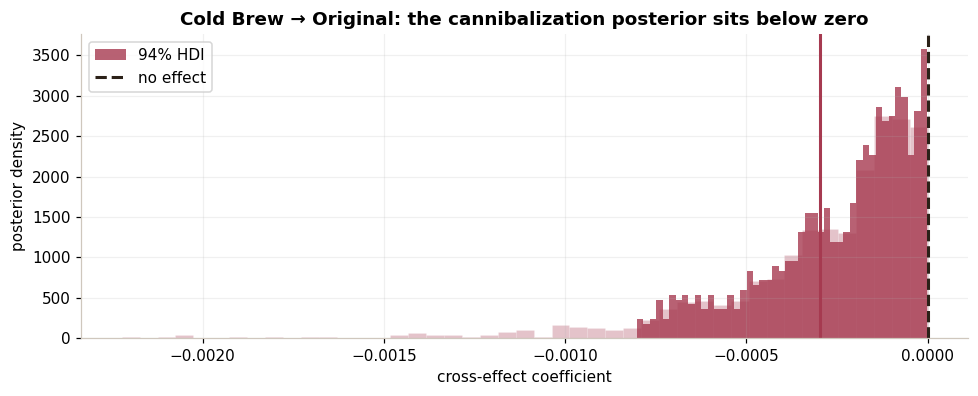

In [8]:
# The cannibalization posterior, drawn — proof the mass sits below zero.
import arviz as az
psi = mv._trace.posterior["psi_matrix"]
target = float(ce["mean"].iloc[0])
cands = {(1, 0): psi[:, :, 1, 0].values.ravel(), (0, 1): psi[:, :, 0, 1].values.ravel()}
samples = min(cands.values(), key=lambda s: abs(float(s.mean()) - target))
lo, hi = az.hdi(samples, hdi_prob=0.94)
fig, ax = plt.subplots(figsize=(9, 3.7))
ax.hist(samples, bins=45, density=True, color=PALETTE["berry"], alpha=.30, edgecolor="white", lw=.4)
sel = samples[(samples >= lo) & (samples <= hi)]
ax.hist(sel, bins=45, density=True, color=PALETTE["berry"], alpha=.8, label="94% HDI")
ax.axvline(0, color=INK, ls="--", lw=2, label="no effect")
ax.axvline(float(samples.mean()), color=PALETTE["berry"], lw=2)
ax.set_title("Cold Brew → Original: the cannibalization posterior sits below zero")
ax.set_xlabel("cross-effect coefficient"); ax.set_ylabel("posterior density")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

### Is this real, or did the prior decide it for us?

Pause on that verdict. The cannibalization prior is **one-sided** by construction —
$\psi = -\,\mathrm{HalfNormal}(\sigma)$, so $\psi \le 0$ with probability one *before any data*. That means
"the interval is below zero" / $P(\psi < 0) \approx 1$ is **partly automatic**: it can just restate the prior.

> A one-sided / informative prior makes a sign statement like $P(\psi < 0) \approx 1$ nearly vacuous — it can
> just restate the prior. The honest replacement is **contraction** / **overlap**: how much did the data
> *move* and *narrow* the parameter beyond the prior?

So we put the cannibalization effect through the harder test. **Contraction** $c = 1 - \mathrm{Var}_{\text{post}}/\mathrm{Var}_{\text{prior}}$
($c \to 1$ means the data pinned it) and the prior↔posterior **overlap** coefficient ($\to 0$ means the two
densities barely touch — strong learning). Both are computed on the free magnitude `psi_1_0_raw`; they are
sign-invariant, so they describe the signed $\psi$ unchanged.

Sampling: [Y_obs, Y_obs_chol_cov, alpha, alpha_shared, beta_media, lambda_Display, lambda_Search, lambda_Social, lambda_TV, psi_1_0_raw]


,parameter,prior_mean,prior_sd,post_mean,post_sd,contraction,contraction_robust,overlap,shift_z,post_ess_bulk,verdict
0,psi_1_0_raw,0.2363,0.1764,0.0003,0.0003,1.0,1.0,0.0525,-1.338,1167.8668,strong


Sampling: [Y_obs, Y_obs_chol_cov, alpha, alpha_shared, beta_media, lambda_Display, lambda_Search, lambda_Social, lambda_TV, psi_1_0_raw]


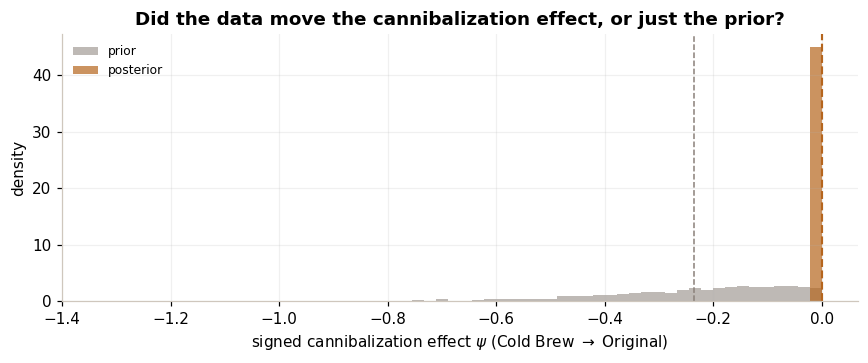

signed psi posterior mean = -0.00030  -> cross-effect contribution to Original = 0.013% of its weekly sales
residual correlation(Original, Cold Brew) = 0.407  (the shared-demand link)
✓ The data was informative about psi (contraction=1.000, overlap=0.052) — and it pinned the DIRECT cross-effect to ~0 (0.01% of sales).


In [9]:
from mmm_framework.diagnostics import plot_prior_posterior_overlay

lrn_mv = mv.compute_parameter_learning(var_names=["psi_1_0_raw"], prior_samples=2000, random_seed=0)
display(lrn_mv.round(4))
row = lrn_mv[lrn_mv.parameter.str.contains("psi_1_0_raw")].iloc[0]
psi_c, psi_ovl = float(row.contraction), float(row.overlap)

# Overlay the prior vs posterior of the SIGNED cannibalization effect (psi = -psi_1_0_raw).
prior_idata = mv.sample_prior_predictive(samples=2000, random_seed=0)
fig, ax = plt.subplots(figsize=(8, 3.4))
plot_prior_posterior_overlay(prior_idata, mv.trace, "psi_1_0_raw", ax=ax, transform=lambda x: -x)
ax.set_xlabel(r"signed cannibalization effect $\psi$ (Cold Brew $\to$ Original)")
ax.set_title("Did the data move the cannibalization effect, or just the prior?")
plt.tight_layout(); plt.show()

# The data WAS informative about psi (contraction ~1) — but informative about WHAT? Read the value
# it pinned psi to, and translate it to an effect size vs Original's sales.
psi_mean = -float(row.post_mean)                          # signed psi = -psi_1_0_raw
xeff = psi_mean * aurora.sales_coldbrew                    # weekly contribution to Original
share = float(np.abs(xeff).mean() / aurora.sales_original.mean())
r_resid = mv.get_correlation_matrix().iloc[0, 1]
print(f"signed psi posterior mean = {psi_mean:.5f}  -> cross-effect contribution to Original "
      f"= {100*share:.3f}% of its weekly sales")
print(f"residual correlation(Original, Cold Brew) = {r_resid:.3f}  (the shared-demand link)")

# DIRECTIONAL, seeded: the data genuinely pinned psi (not merely restated the one-sided prior)...
assert psi_c > 0.5, f"psi contraction too low ({psi_c:.3f}) — would be prior-dominated, not learned"
assert psi_ovl < 0.3, f"psi prior/posterior overlap too high ({psi_ovl:.3f}) — posterior ~ prior"
# ...and what it pinned it to is essentially zero (a negligible DIRECT cross-effect).
assert share < 0.02, f"direct cross-effect should be a tiny share of sales; got {100*share:.2f}%"
print(f"✓ The data was informative about psi (contraction={psi_c:.3f}, overlap={psi_ovl:.3f}) — "
      f"and it pinned the DIRECT cross-effect to ~0 ({100*share:.2f}% of sales).")

**The honest verdict — and it flips the naive one.** The diagnostic clears the first hurdle: the data *was*
informative about $\psi$ (contraction $\approx 1$, overlap $\approx 0$), so this is **not** a prior artifact.
But "the data spoke" is not "the effect is real" — read *what* it said. The data pins $\psi$ to **essentially
zero** (a direct cross-effect worth a fraction of a percent of Original's sales). So the honest conclusion is
the **opposite** of the sign-only verdict: within this model there is **little direct cannibalization**. The
two products genuinely co-move, but through the **positive residual correlation** (≈0.4 — Aurora's shared
**demand** wave, charted next), not a Cold-Brew→Original cannibalization arrow.

> **The lesson.** $P(\psi<0)\approx 1$ was the near-vacuous part: under a one-sided prior the sign is
> automatic. Contraction tells you the **data was informative**; the posterior **mean** tells you it found a
> **negligible** effect. (Contrast Chapter 2's adstock blend weights, which the data could not pin at all —
> prior-dominated.) The substitution baked into Aurora's data isn't recovered as a *direct* cross-effect by
> this weakly-identified multivariate model; it surfaces as shared-demand co-movement instead.

Here is where the products' co-movement actually lives: even after media is accounted for, the two
products' residuals **move together** — Aurora's shared demand wave lifts Original and Cold Brew at the
same time. This positive correlation, not the (near-zero) direct cross-effect, is the real linkage.

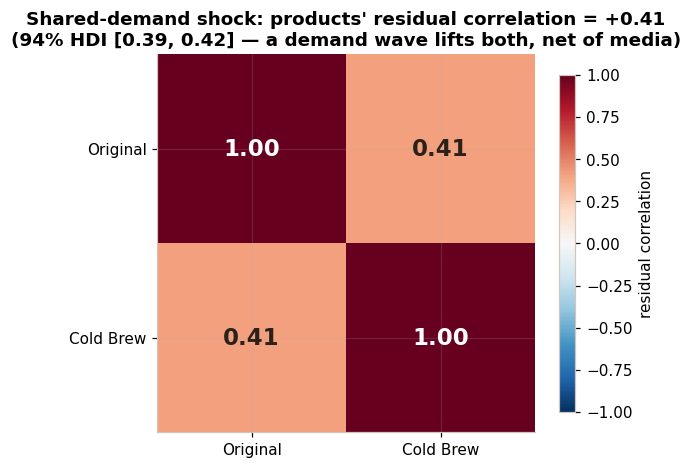

In [10]:
# The model's OTHER finding: after media, the two products' residuals still move together —
# the shared-demand shock. Shown as the outcome residual-correlation matrix.
import arviz as az
cm = mv.get_correlation_matrix()                 # DataFrame, indexed by outcome_names
labels = list(PRODUCTS)                          # ['Original', 'Cold Brew'] = outcome order
M = cm.values
off = mv._trace.posterior["Y_obs_correlation"].values[:, :, 0, 1].ravel()
lo, hi = az.hdi(off, hdi_prob=0.94)
fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(M[i, j]) > 0.55 else INK, fontsize=15, weight="bold")
cbar = fig.colorbar(im, ax=ax, shrink=0.82); cbar.set_label("residual correlation")
ax.set_title(f"Shared-demand shock: products' residual correlation = {M[0, 1]:+.2f}\n"
             f"(94% HDI [{lo:.2f}, {hi:.2f}] — a demand wave lifts both, net of media)")
plt.tight_layout(); plt.show()

## Extended models serialize too

In [11]:
from pathlib import Path
Path("artifacts").mkdir(exist_ok=True)
nested.save("artifacts/aurora_nested")
reloaded = NestedMMM.load("artifacts/aurora_nested")
print("reloaded nested model, mediators:", reloaded.mediator_names,
      "| trace restored:", reloaded._trace is not None)

reloaded nested model, mediators: ['awareness'] | trace restored: True


### Takeaways
- **NestedMMM** shows TV/Display are **brand engines** — their value lives in the awareness pathway the
  base model is blind to. Mystery of the undervalued channels: solved.
- **MultivariateMMM** ties the two products together through a **shared demand shock** (positive
  residual correlation). The Cold Brew → Original *cross-effect's* interval sits below zero, but the
  **learning diagnostic** shows the data pins that direct effect ~0 — the one-sided prior made the sign
  near-automatic, so the honest read is "co-move via shared demand," and the two products are planned
  *together* for that reason.

Now we have everything: a causal map, experiment anchoring, brand-pathway value, and product
interactions. Time to make it a decision — and a board deck: **`04_reporting.ipynb`**.